In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
import pandas as pd

# Paste your copied path between the quotes
folder_path = '/content/drive/MyDrive/My analysis/Bycicle project'

# Check if it works (this should list your files)
print(os.listdir(folder_path))

['202503-divvy-tripdata.csv', '202504-divvy-tripdata.csv', '202505-divvy-tripdata.csv', '202506-divvy-tripdata.csv', '202507-divvy-tripdata.csv', '202508-divvy-tripdata.csv', '202509-divvy-tripdata.csv', '202510-divvy-tripdata.csv', '202511-divvy-tripdata.csv', '202512-divvy-tripdata.csv', '202501-divvy-tripdata.csv', '202602-divvy-tripdata.csv', '202603-divvy-tripdata.csv', '__MACOSX']


In [3]:
# Create a list of all CSV files in that folder
file_list = glob.glob(os.path.join(folder_path, "*.csv"))

# Read them all into one "DataFrame"
# We use encoding='latin1' just in case there are weird characters in your data
df = pd.concat((pd.read_csv(f, encoding='latin1') for f in file_list), ignore_index=True)

print(f"Done! Combined {len(file_list)} files into one table.")

Done! Combined 13 files into one table.


In [4]:
# 1. Remove exact duplicate rows
df = df.drop_duplicates()

# 2. Fix Column Names (removes accidental spaces like "Price " vs "Price")
df.columns = df.columns.str.strip()

# 3. Handle Missing Values
# This fills empty text cells with 'N/A' so they don't break your analysis later
df = df.fillna("N/A")

print("Cleaning complete.")

Cleaning complete.


In [5]:
# Show the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Show the column names and data types (numbers vs text)
print("\n--- COLUMN INFO ---")
df.info()

--- FIRST 5 ROWS ---


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,16CBE9844D401954,electric_bike,2025-03-18 08:39:20.065,2025-03-18 08:51:37.633,N/A,N/A,Canal St & Jackson Blvd,13138,41.91,-87.67,41.878125,-87.639968,member
1,1CB408029E2B5F74,electric_bike,2025-03-24 16:04:22.239,2025-03-24 16:27:41.347,N/A,N/A,Albany Ave & Bloomingdale Ave,15655,41.86,-87.68,41.914027,-87.705126,member
2,7B6A76CD0F204D08,electric_bike,2025-03-10 16:06:19.708,2025-03-10 16:29:17.457,N/A,N/A,Albany Ave & Bloomingdale Ave,15655,41.86,-87.68,41.914027,-87.705126,member
3,4F7084E3D75CDE31,electric_bike,2025-03-21 14:28:14.579,2025-03-21 14:35:06.160,N/A,N/A,Canal St & Jackson Blvd,13138,41.87,-87.63,41.878125,-87.639968,member
4,E419A570A5A0475B,electric_bike,2025-03-14 17:54:14.484,2025-03-14 18:17:53.254,N/A,N/A,Albany Ave & Bloomingdale Ave,15655,41.89,-87.67,41.914027,-87.705126,casual



--- COLUMN INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5918699 entries, 0 to 5918698
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             object 
 11  end_lng             object 
 12  member_casual       object 
dtypes: float64(2), object(11)
memory usage: 587.0+ MB


In [6]:
output_path = os.path.join(folder_path, "Master_Combined_Data.csv")
df.to_csv(output_path, index=False)

print(f"Success! Your master file is saved at: {output_path}")

Success! Your master file is saved at: /content/drive/MyDrive/My analysis/Bycicle project/Master_Combined_Data.csv


In [ ]:
# Calculate the average ride length for each group
# (Assuming your column is named 'ride_length' or similar)
avg_duration = df.groupby('member_casual')['ride_length'].mean()
print("Average Ride Duration (in minutes):")
print(avg_duration)

In [8]:
# Convert to datetime format
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Calculate ride length in minutes
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Extract the day of the week
df['day_of_week'] = df['started_at'].dt.day_name()

print("Time columns are ready for analysis.")

Time columns are ready for analysis.


In [9]:
# Compare average and median ride length
duration_comparison = df.groupby('member_casual')['ride_length'].agg(['mean', 'median'])
print("Ride Duration Comparison (Minutes):")
print(duration_comparison)

Ride Duration Comparison (Minutes):
                    mean     median
member_casual                      
casual         22.522004  11.318367
member         12.367572   8.537817


In [10]:
# Count rides per day for each group
# We define the order to make sure the chart looks right (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

usage_by_day = df.groupby(['day_of_week', 'member_casual']).size().unstack().reindex(day_order)
print("Usage Patterns Throughout the Week:")
print(usage_by_day)

Usage Patterns Throughout the Week:
member_casual  casual  member
day_of_week                  
Monday         245896  548669
Tuesday        236976  612169
Wednesday      231298  589913
Thursday       268264  611679
Friday         333653  563438
Saturday       436514  482448
Sunday         348767  409015


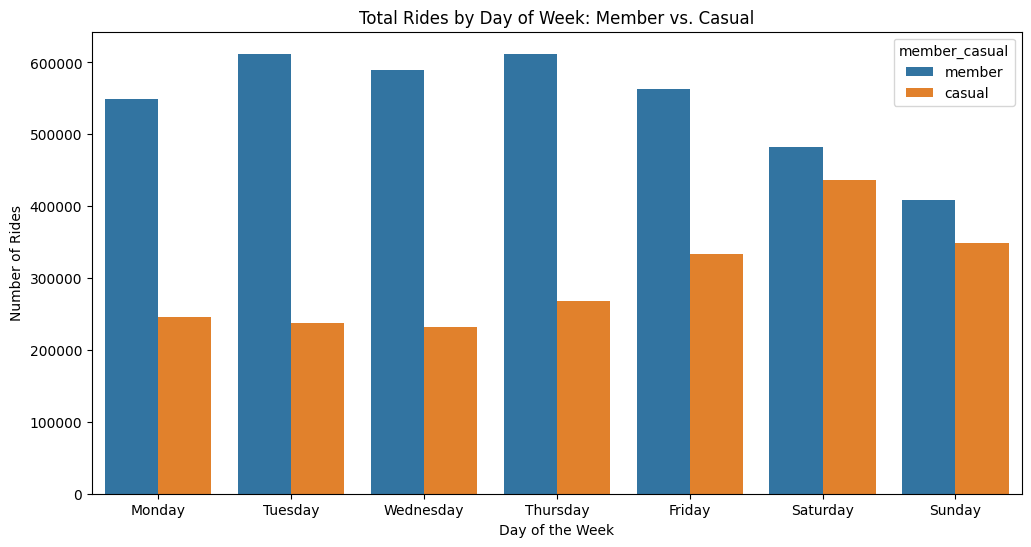

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(x='day_of_week', hue='member_casual', data=df, order=day_order)
plt.title('Total Rides by Day of Week: Member vs. Casual')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Rides')
plt.show()

In [12]:
# Create a 'is_weekend' flag
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Compare average rides per day
weekend_summary = df.groupby(['member_casual', 'is_weekend']).size().unstack()
weekend_summary.columns = ['Weekday_Total', 'Weekend_Total']

# Get the average per day (5 weekdays vs 2 weekend days)
weekend_summary['Avg_Rides_Per_Weekday'] = weekend_summary['Weekday_Total'] / 5
weekend_summary['Avg_Rides_Per_Weekend_Day'] = weekend_summary['Weekend_Total'] / 2

print("Daily Average Comparison:")
print(weekend_summary[['Avg_Rides_Per_Weekday', 'Avg_Rides_Per_Weekend_Day']])

Daily Average Comparison:
               Avg_Rides_Per_Weekday  Avg_Rides_Per_Weekend_Day
member_casual                                                  
casual                      263217.4                   392640.5
member                      585173.6                   445731.5


In [13]:
print("--- Top 5 Start Stations for CASUAL Riders ---")
print(df[df['member_casual'] == 'casual']['start_station_name'].value_counts().head(5))

print("\n--- Top 5 Start Stations for MEMBER Riders ---")
print(df[df['member_casual'] == 'member']['start_station_name'].value_counts().head(5))

--- Top 5 Start Stations for CASUAL Riders ---
start_station_name
N/A                                  451265
DuSable Lake Shore Dr & Monroe St     32828
Navy Pier                             30007
Streeter Dr & Grand Ave               23326
Michigan Ave & Oak St                 23217
Name: count, dtype: int64

--- Top 5 Start Stations for MEMBER Riders ---
start_station_name
N/A                             799024
Kingsbury St & Kinzie St         28136
Clinton St & Washington Blvd     25417
Canal St & Madison St            23925
Clinton St & Madison St          22710
Name: count, dtype: int64


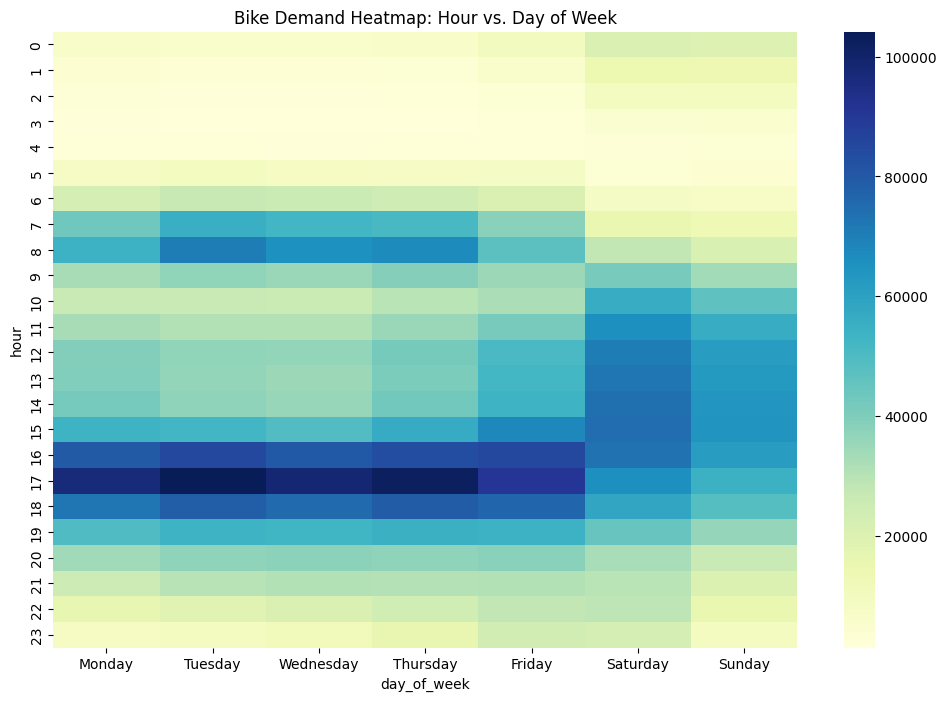

In [14]:
# Create an hour column
df['hour'] = df['started_at'].dt.hour

# Pivot the data for a heatmap
heatmap_data = df.groupby(['hour', 'day_of_week']).size().unstack(fill_value=0)
heatmap_data = heatmap_data[day_order] # Keep days in order

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Bike Demand Heatmap: Hour vs. Day of Week')
plt.show()

In [16]:
# Create a filter for peak commute hours (7-9 AM and 4-6 PM)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18])

# See how many Casual rides happen during rush hour vs. non-rush hour
commuter_casuals = df[df['member_casual'] == 'casual'].groupby('is_rush_hour').size()

print("Casual Rider Rush Hour Usage:")
print(commuter_casuals)

Casual Rider Rush Hour Usage:
is_rush_hour
False    1340961
True      760407
dtype: int64
